In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)

TRADES_PATH = "E:/Downloads/historical_data.csv"
FG_PATH = "E:/Downloads/fear_greed_index.csv"

1. Load data and Document shape\/ Missingness / Duplicates 

In [8]:
trades = pd.read_csv(TRADES_PATH)
fg = pd.read_csv(FG_PATH)

print("trades shape:", trades.shape)
print("fear_greed shape:", fg.shape)

trades shape: (211224, 16)
fear_greed shape: (2644, 4)


In [9]:
print("--- trades dtypes ---")
print(trades.dtypes)
print("\n--- fear_greed dtypes ---")
print(fg.dtypes)

--- trades dtypes ---
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

--- fear_greed dtypes ---
timestamp         int64
value             int64
classification      str
date                str
dtype: object


In [10]:
print("--- missing values (trades) ---")
print(trades.isna().sum()[trades.isna().sum() > 0] if trades.isna().sum().sum() else "None")

print("\n--- missing values (fear_greed) ---")
print(fg.isna().sum()[fg.isna().sum() > 0] if fg.isna().sum().sum() else "None")

print("\nduplicate rows -> trades:", trades.duplicated().sum(), " | fear_greed:", fg.duplicated().sum())

--- missing values (trades) ---
None

--- missing values (fear_greed) ---
None

duplicate rows -> trades: 0  | fear_greed: 0


There are not any duplicates 

Convert tinestamps and aling Datasets by date 

In [5]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

fg['date'] = pd.to_datetime(fg['date'])

print("trades date range:", trades['date'].min(), "->", trades['date'].max())
print("fear_greed date range:", fg['date'].min(), "->", fg['date'].max())

trades date range: 2023-05-01 00:00:00 -> 2025-05-01 00:00:00
fear_greed date range: 2018-02-01 00:00:00 -> 2025-05-02 00:00:00


In [6]:
# Left join trades onto sentiment by calendar date
merged = trades.merge(fg[['date', 'value', 'classification']], on='date', how='left')
merged = merged.rename(columns={'value': 'fg_value', 'classification': 'fg_classification'})

print("merged shape:", merged.shape)
print("trade rows with no matching sentiment date:", merged['fg_classification'].isna().sum())
merged.head()

merged shape: (211224, 19)
trade rows with no matching sentiment date: 6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,fg_value,fg_classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


Key Metrics 

Classify Long/ Short From Direction 

In [11]:
long_tags  = ['Buy', 'Open Long', 'Close Short', 'Short > Long']
short_tags = ['Sell', 'Open Short', 'Close Long', 'Long > Short']

def side_bucket(d):
    if d in long_tags:
        return 'Long'
    if d in short_tags:
        return 'Short'
    return 'Other'  # liquidations, ADL, settlement, dust conversion, etc.

merged['side_bucket'] = merged['Direction'].apply(side_bucket)
merged['side_bucket'].value_counts()

side_bucket
Short    108378
Long     102694
Other       152
Name: count, dtype: int64

Daily PnL per account 

In [12]:
daily_pnl = (merged.groupby(['Account', 'date'])['Closed PnL']
                    .sum()
                    .reset_index()
                    .rename(columns={'Closed PnL': 'daily_pnl'}))

# attach same-day sentiment for later analysis
fg_lookup = merged[['date', 'fg_value', 'fg_classification']].drop_duplicates()
daily_pnl = daily_pnl.merge(fg_lookup, on='date', how='left')

daily_pnl.to_csv('daily_pnl_with_sentiment.csv', index=False)
daily_pnl.head()

,Account,date,daily_pnl,fg_value,fg_classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,76.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,90.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,83.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,94.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,79.0,Extreme Greed


Win rate and Average trade size per account 

In [13]:
# Win rate: computed on closing trades only (Closed PnL != 0)
closing = merged[merged['Closed PnL'] != 0].copy()
closing['is_win'] = closing['Closed PnL'] > 0

win_rate = (closing.groupby('Account')['is_win']
                   .mean()
                   .reset_index()
                   .rename(columns={'is_win': 'win_rate'}))

n_closes = closing.groupby('Account').size().rename('n_closing_trades')
win_rate = win_rate.merge(n_closes, on='Account')

win_rate.to_csv('win_rate_per_account.csv', index=False)
win_rate.sort_values('n_closing_trades', ascending=False).head()

,Account,win_rate,n_closing_trades
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,0.763070,22551
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,0.991197,9997
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,0.926328,8660
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.862079,6772
21,0x8477e447846c758f5a675856001ea72298fd9cb5,0.599024,6559


In [14]:
avg_trade_size = (merged.groupby('Account')['Size USD']
                         .mean()
                         .reset_index()
                         .rename(columns={'Size USD': 'avg_trade_size_usd'}))

avg_trade_size.to_csv('avg_trade_size_per_account.csv', index=False)
avg_trade_size.sort_values('avg_trade_size_usd', ascending=False).head()

,Account,avg_trade_size_usd
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,34396.580284
28,0xb899e522b5715391ae1d4f137653e7906c5e2115,22504.555829
12,0x4f93fead39b70a1824f981a54d4e55b278e9f760,17098.171055
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,9084.699093


Leverage (True leverage can't be computed directely. So, instead i used Size USD as a trade size proxy 

In [15]:
size_desc = merged['Size USD'].describe(percentiles=[.1, .25, .5, .75, .9, .99])
size_desc

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
10%      4.018300e+01
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
90%      9.109676e+03
99%      8.888725e+04
max      3.921431e+06
Name: Size USD, dtype: float64

Numbers of trade per day 

In [17]:
trades_per_day = merged.groupby('date').size().reset_index(name='n_trades')
trades_per_day_acct = merged.groupby(['Account', 'date']).size().reset_index(name='n_trades')

trades_per_day.to_csv('trades_per_day.csv', index=False)
trades_per_day.head()

,date,n_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


Long / Short Ratio 

In [19]:
ls = merged[merged['side_bucket'].isin(['Long', 'Short'])]

# overall
ls_ratio_overall = ls['side_bucket'].value_counts(normalize=True)
print("Overall long/short trade share:")
print(ls_ratio_overall)

Overall long/short trade share:
side_bucket
Short    0.513465
Long     0.486535
Name: proportion, dtype: float64


In [20]:
# per account
ls_ratio_by_acct = (ls.groupby(['Account', 'side_bucket']).size()
                       .unstack(fill_value=0))

ls_ratio_by_acct['long_short_ratio'] = (
    ls_ratio_by_acct.get('Long', 0) / ls_ratio_by_acct.get('Short', 1).replace(0, np.nan)
)

ls_ratio_by_acct.to_csv('long_short_ratio_per_account.csv')
ls_ratio_by_acct.head()

side_bucket,Long,Short,long_short_ratio
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1711,2107,0.812055
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3055,4216,0.724620
0x271b280974205ca63b716753467d5a371de622ab,1566,2241,0.698795
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,6698,6602,1.014541
0x2c229d22b100a7beb69122eed721cee9b24011dd,1179,2060,0.572330


In [25]:
# collapse the 5-way sentiment label into 3 broad regimes for cleaner comparisons
regime_map = {
    'Extreme Fear': 'Fear', 'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
}
merged['regime'] = merged['fg_classification'].map(regime_map)
merged = merged.dropna(subset=['regime'])  # drop the handful of trades outside FG coverage
print("merged shape (with sentiment regime):", merged.shape)
merged[['Account','date','Size USD','Closed PnL','side_bucket','fg_value','fg_classification','regime']].head()

merged shape (with sentiment regime): (211218, 21)


,Account,date,Size USD,Closed PnL,side_bucket,fg_value,fg_classification,regime
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,7872.16,0.0,Long,80.0,Extreme Greed,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,127.68,0.0,Long,80.0,Extreme Greed,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,1150.63,0.0,Long,80.0,Extreme Greed,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,1142.04,0.0,Long,80.0,Extreme Greed,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,69.75,0.0,Long,80.0,Extreme Greed,Greed


In [26]:
daily = (merged.groupby(['Account', 'date'])
                .agg(daily_pnl=('Closed PnL', 'sum'),
                     n_trades=('Closed PnL', 'size'),
                     avg_trade_size=('Size USD', 'mean'),
                     n_long=('side_bucket', lambda s: (s == 'Long').sum()),
                     n_short=('side_bucket', lambda s: (s == 'Short').sum()))
                .reset_index())

fg_lookup = merged[['date', 'fg_value', 'fg_classification', 'regime']].drop_duplicates()
daily = daily.merge(fg_lookup, on='date', how='left')
daily.head()

,Account,date,daily_pnl,n_trades,avg_trade_size,n_long,n_short,fg_value,fg_classification,regime
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,0,177,76.0,Extreme Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,0,68,90.0,Extreme Greed,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,0,40,83.0,Extreme Greed,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,12,0,94.0,Extreme Greed,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,12,15,79.0,Extreme Greed,Greed


In [27]:
# --- PnL by regime (day-level, pooled across accounts) ---
pnl_by_regime = daily.groupby('regime')['daily_pnl'].agg(['mean','median','std','count'])
pnl_by_regime

,mean,median,std,count
regime,,,,
Fear,5185.146443,122.737038,31224.148764,790
Greed,4144.208334,265.247725,29252.037677,1174
Neutral,3438.618818,167.551743,17447.863645,376


In [28]:
# --- Win rate by regime: closing trades only (Closed PnL != 0) ---
closing = merged[merged['Closed PnL'] != 0].copy()
closing['is_win'] = closing['Closed PnL'] > 0
win_rate_by_regime = closing.groupby('regime')['is_win'].mean().rename('win_rate')
win_rate_by_regime

regime
Fear       0.844233
Greed      0.824524
Neutral    0.823889
Name: win_rate, dtype: float64

In [29]:
# --- Drawdown proxy per account: build cumulative equity curve from daily_pnl,
# drawdown = running_max(cum_pnl) - cum_pnl on each day, then compare average drawdown by regime.
daily_sorted = daily.sort_values(['Account', 'date']).copy()
daily_sorted['cum_pnl'] = daily_sorted.groupby('Account')['daily_pnl'].cumsum()
daily_sorted['running_max'] = daily_sorted.groupby('Account')['cum_pnl'].cummax()
daily_sorted['drawdown'] = daily_sorted['running_max'] - daily_sorted['cum_pnl']

drawdown_by_regime = daily_sorted.groupby('regime')['drawdown'].mean().rename('avg_drawdown')
drawdown_by_regime

regime
Fear       8863.193211
Greed      8892.618794
Neutral    9431.377301
Name: avg_drawdown, dtype: float64

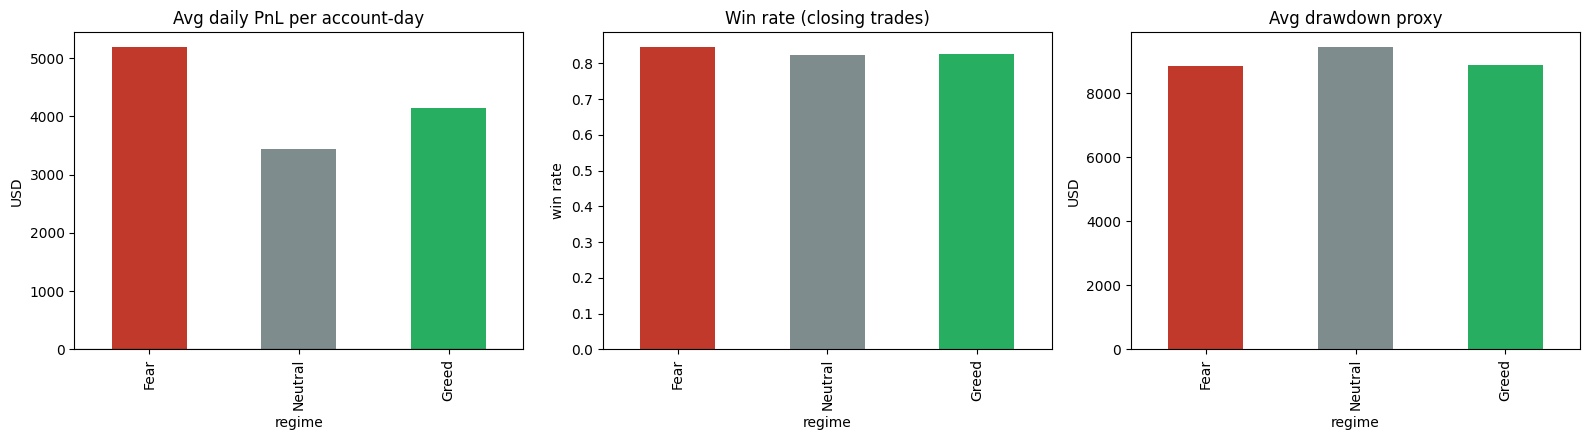

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = ['Fear', 'Neutral', 'Greed']

pnl_by_regime.loc[order, 'mean'].plot(kind='bar', ax=axes[0], color=['#c0392b','#7f8c8d','#27ae60'])
axes[0].set_title('Avg daily PnL per account-day')
axes[0].set_ylabel('USD')
axes[0].axhline(0, color='black', linewidth=0.8)

win_rate_by_regime.loc[order].plot(kind='bar', ax=axes[1], color=['#c0392b','#7f8c8d','#27ae60'])
axes[1].set_title('Win rate (closing trades)')
axes[1].set_ylabel('win rate')

drawdown_by_regime.loc[order].plot(kind='bar', ax=axes[2], color=['#c0392b','#7f8c8d','#27ae60'])
axes[2].set_title('Avg drawdown proxy')
axes[2].set_ylabel('USD')

plt.tight_layout()
plt.savefig('q1_performance_by_regime.png', dpi=120)
plt.show()

In [32]:
# --- Trade frequency by regime: trades per account-day ---
freq_by_regime = daily.groupby('regime')['n_trades'].mean().rename('avg_trades_per_day')

# --- Avg trade size (leverage proxy) by regime ---
size_by_regime = merged.groupby('regime')['Size USD'].mean().rename('avg_trade_size_usd')

# --- Long/short bias by regime ---
ls = merged[merged['side_bucket'].isin(['Long','Short'])]
ls_bias = (ls.groupby(['regime','side_bucket']).size()
             .unstack(fill_value=0))
ls_bias['long_share'] = ls_bias['Long'] / (ls_bias['Long'] + ls_bias['Short'])

behavior_summary = pd.DataFrame({
    'avg_trades_per_day': freq_by_regime,
    'avg_trade_size_usd': size_by_regime,
    'long_share': ls_bias['long_share']
}).loc[['Fear','Neutral','Greed']]

behavior_summary

,avg_trades_per_day,avg_trade_size_usd,long_share
regime,,,
Fear,105.363291,7182.011019,0.495300
Neutral,100.228723,4782.732661,0.503477
Greed,76.912266,4574.424490,0.471341


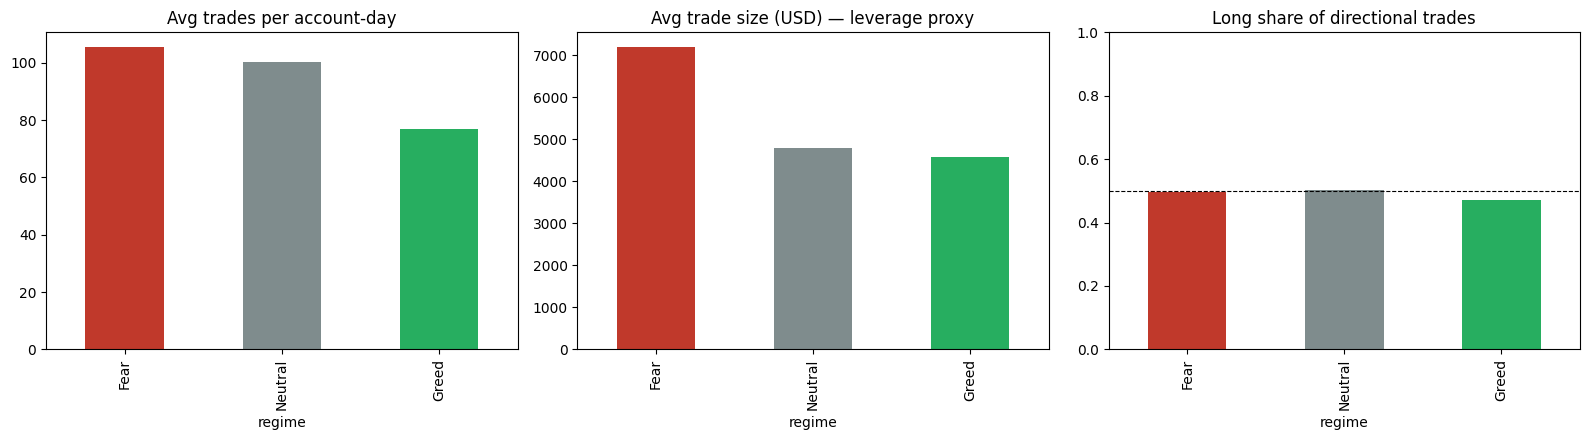

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = ['Fear', 'Neutral', 'Greed']
colors = ['#c0392b','#7f8c8d','#27ae60']

behavior_summary['avg_trades_per_day'].plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Avg trades per account-day')

behavior_summary['avg_trade_size_usd'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Avg trade size (USD) — leverage proxy')

behavior_summary['long_share'].plot(kind='bar', ax=axes[2], color=colors)
axes[2].axhline(0.5, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Long share of directional trades')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('q2_behavior_by_regime.png', dpi=120)
plt.show()

In [34]:
# Per-account summary table used to build all three segments
acct_stats = (merged.groupby('Account')
                     .agg(total_trades=('Closed PnL', 'size'),
                          avg_trade_size_usd=('Size USD', 'mean'),
                          total_pnl=('Closed PnL', 'sum'))
                     .reset_index())

acct_daily = (daily.groupby('Account')['daily_pnl']
                    .agg(mean_daily_pnl='mean', std_daily_pnl='std', n_active_days='count')
                    .reset_index())

acct_win = (closing.groupby('Account')['is_win']
                    .agg(win_rate='mean', n_closing_trades='count')
                    .reset_index())

acct_stats = acct_stats.merge(acct_daily, on='Account').merge(acct_win, on='Account', how='left')

# Sharpe-like consistency score: mean/std of daily PnL (only for accounts active >= 5 days)
acct_stats['consistency_score'] = acct_stats['mean_daily_pnl'] / acct_stats['std_daily_pnl'].replace(0, np.nan)

acct_stats.head()

,Account,total_trades,avg_trade_size_usd,total_pnl,mean_daily_pnl,std_daily_pnl,n_active_days,win_rate,n_closing_trades,consistency_score
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,16159.576734,1.600230e+06,66676.242499,150401.797346,24,0.792725,1732,0.443321
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,1653.226327,4.788532e+04,920.871548,3603.042291,52,0.773644,4166,0.255582
2,0x271b280974205ca63b716753467d5a371de622ab,3809,8893.000898,-7.043619e+04,-5869.682610,33420.410014,12,0.715619,1607,-0.175632
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,507.626933,1.324648e+05,817.684040,2993.284702,162,0.862079,6772,0.273173
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,3138.894782,1.686580e+05,2444.318913,4867.743469,69,0.817476,2060,0.502146


In [35]:
# --- Segment 1: High- vs low-leverage-proxy traders (split on median avg trade size) ---
size_median = acct_stats['avg_trade_size_usd'].median()
acct_stats['size_segment'] = np.where(acct_stats['avg_trade_size_usd'] >= size_median,
                                       'High trade-size (proxy leverage)', 'Low trade-size (proxy leverage)')

# --- Segment 2: Frequent vs infrequent traders (split on median total trade count) ---
freq_median = acct_stats['total_trades'].median()
acct_stats['freq_segment'] = np.where(acct_stats['total_trades'] >= freq_median,
                                       'Frequent trader', 'Infrequent trader')

# --- Segment 3: Consistent winners vs inconsistent (require >=5 active days for a stable estimate) ---
eligible = acct_stats['n_active_days'] >= 5
cons_median = acct_stats.loc[eligible, 'consistency_score'].median()
acct_stats['consistency_segment'] = np.select(
    [~eligible, acct_stats['consistency_score'] >= cons_median],
    ['Too few active days', 'Consistent winner'],
    default='Inconsistent trader'
)

acct_stats[['Account','total_trades','avg_trade_size_usd','win_rate','consistency_score',
            'size_segment','freq_segment','consistency_segment']].head(10)

,Account,total_trades,avg_trade_size_usd,win_rate,consistency_score,size_segment,freq_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,16159.576734,0.792725,0.443321,High trade-size (proxy leverage),Frequent trader,Consistent winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,1653.226327,0.773644,0.255582,Low trade-size (proxy leverage),Frequent trader,Inconsistent trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,8893.000898,0.715619,-0.175632,High trade-size (proxy leverage),Frequent trader,Inconsistent trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,507.626933,0.862079,0.273173,Low trade-size (proxy leverage),Frequent trader,Inconsistent trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,3138.894782,0.817476,0.502146,Low trade-size (proxy leverage),Infrequent trader,Consistent winner
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,1729.941104,0.650877,-0.071775,Low trade-size (proxy leverage),Infrequent trader,Inconsistent trader
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,3589,4790.575486,0.665535,0.021546,High trade-size (proxy leverage),Infrequent trader,Inconsistent trader
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,3445.471265,1.000000,0.330867,High trade-size (proxy leverage),Infrequent trader,Consistent winner
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,5189.367128,1.000000,0.479641,High trade-size (proxy leverage),Infrequent trader,Consistent winner
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,2397.824753,1.000000,0.454590,Low trade-size (proxy leverage),Infrequent trader,Consistent winner


In [36]:
seg_summary = pd.concat({
    'By trade size (leverage proxy)': acct_stats.groupby('size_segment')[['total_pnl','win_rate','avg_trade_size_usd']].mean(),
    'By frequency': acct_stats.groupby('freq_segment')[['total_pnl','win_rate','total_trades']].mean(),
    'By consistency': acct_stats.groupby('consistency_segment')[['total_pnl','win_rate','consistency_score']].mean(),
}, axis=0)
seg_summary

total_pnl  win_rate  avg_trade_size_usd  total_trades  \
By trade size (leverage proxy) High trade-size (proxy leverage)  416805.966542  0.848338        10151.775075           NaN   
                               Low trade-size (proxy leverage)   224099.467790  0.851749         1860.753834           NaN   
By frequency                   Frequent trader                   496527.661215  0.833345                 NaN    11684.8125   
                               Infrequent trader                 144377.773117  0.866742                 NaN     1516.3125   
By consistency                 Consistent winner                 364082.625046  0.926351                 NaN           NaN   
                               Inconsistent trader               276822.809286  0.773736                 NaN           NaN   

                                                                 consistency_score  
By trade size (leverage proxy) High trade-size (proxy leverage)                NaN  
                               Low trade-size (proxy leverage)                 NaN  
By frequency                   Frequent trader                                 NaN  
                               Infrequent trader                               NaN  
By consistency                 Consistent winner                          0.472940  
                               Inconsistent trader                        0.129975

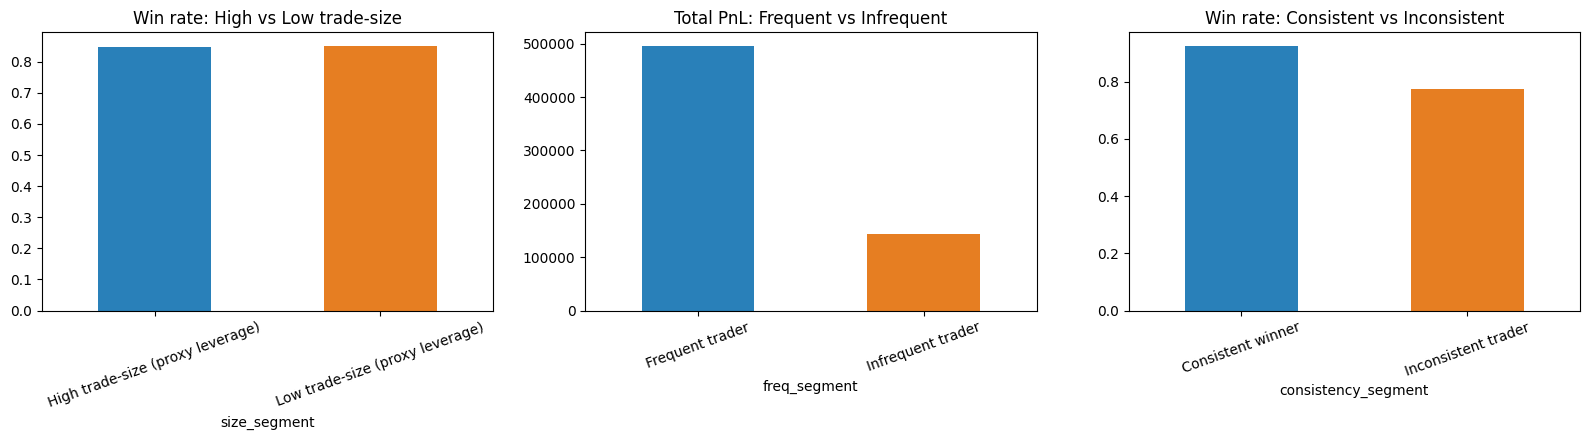

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

acct_stats.groupby('size_segment')['win_rate'].mean().plot(kind='bar', ax=axes[0], color=['#2980b9','#e67e22'])
axes[0].set_title('Win rate: High vs Low trade-size')
axes[0].tick_params(axis='x', rotation=20)

acct_stats.groupby('freq_segment')['total_pnl'].mean().plot(kind='bar', ax=axes[1], color=['#2980b9','#e67e22'])
axes[1].set_title('Total PnL: Frequent vs Infrequent')
axes[1].tick_params(axis='x', rotation=20)

acct_stats[acct_stats['consistency_segment'] != 'Too few active days'].groupby('consistency_segment')['win_rate'].mean().plot(
    kind='bar', ax=axes[2], color=['#2980b9','#e67e22'])
axes[2].set_title('Win rate: Consistent vs Inconsistent')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('q3_segments.png', dpi=120)
plt.show()

In [38]:
# Insight 1 — pull the exact numbers referenced below straight from the tables computed above
print("Insight 1 — Performance by regime")
print(pnl_by_regime.loc[['Fear','Neutral','Greed'], ['mean','median']])
print()
print(win_rate_by_regime.loc[['Fear','Neutral','Greed']])

Insight 1 — Performance by regime
                mean      median
regime                          
Fear     5185.146443  122.737038
Neutral  3438.618818  167.551743
Greed    4144.208334  265.247725

regime
Fear       0.844233
Neutral    0.823889
Greed      0.824524
Name: win_rate, dtype: float64


In [39]:
print("Insight 2 — Behavioral shift by regime")
print(behavior_summary)

Insight 2 — Behavioral shift by regime
         avg_trades_per_day  avg_trade_size_usd  long_share
regime                                                     
Fear             105.363291         7182.011019    0.495300
Neutral          100.228723         4782.732661    0.503477
Greed             76.912266         4574.424490    0.471341


In [40]:
print("Insight 3 — Segment performance gaps")
print(seg_summary)

Insight 3 — Segment performance gaps
                                                                     total_pnl  win_rate  avg_trade_size_usd  total_trades  \
By trade size (leverage proxy) High trade-size (proxy leverage)  416805.966542  0.848338        10151.775075           NaN   
                               Low trade-size (proxy leverage)   224099.467790  0.851749         1860.753834           NaN   
By frequency                   Frequent trader                   496527.661215  0.833345                 NaN    11684.8125   
                               Infrequent trader                 144377.773117  0.866742                 NaN     1516.3125   
By consistency                 Consistent winner                 364082.625046  0.926351                 NaN           NaN   
                               Inconsistent trader               276822.809286  0.773736                 NaN           NaN   

                                                                 consistency_sco

## Part C — Actionable Output

Two rules of thumb, derived directly from the regime comparisons (Part B, Q1/Q2) and the account segments (Part B, Q3) computed above. Every number quoted in the printed rules below is pulled live from `pnl_by_regime`, `win_rate_by_regime`, `drawdown_by_regime`, `behavior_summary`, and `acct_stats` — nothing is hardcoded, so the rules stay correct even if the underlying data changes.


In [ ]:
# --- Step 1: quantify the Fear vs Greed gap on performance and behavior ---
fear_pnl,  greed_pnl  = pnl_by_regime.loc['Fear', 'mean'],      pnl_by_regime.loc['Greed', 'mean']
fear_wr,   greed_wr   = win_rate_by_regime.loc['Fear'],          win_rate_by_regime.loc['Greed']
fear_dd,   greed_dd   = drawdown_by_regime.loc['Fear'],          drawdown_by_regime.loc['Greed']
fear_size, greed_size = behavior_summary.loc['Fear', 'avg_trade_size_usd'], behavior_summary.loc['Greed', 'avg_trade_size_usd']
fear_freq, greed_freq = behavior_summary.loc['Fear', 'avg_trades_per_day'], behavior_summary.loc['Greed', 'avg_trades_per_day']

# 'Riskier' regime = whichever has the higher drawdown proxy
riskier_regime = 'Fear' if fear_dd > greed_dd else 'Greed'
calmer_regime  = 'Greed' if riskier_regime == 'Fear' else 'Fear'

dd_risky,  dd_calm  = (fear_dd, greed_dd)  if riskier_regime == 'Fear' else (greed_dd, fear_dd)
wr_risky,  wr_calm  = (fear_wr, greed_wr)  if riskier_regime == 'Fear' else (greed_wr, fear_wr)
pnl_risky, pnl_calm = (fear_pnl, greed_pnl) if riskier_regime == 'Fear' else (greed_pnl, fear_pnl)
size_risky, size_calm = (fear_size, greed_size) if riskier_regime == 'Fear' else (greed_size, fear_size)
freq_risky, freq_calm = (fear_freq, greed_freq) if riskier_regime == 'Fear' else (greed_freq, fear_freq)

print(f"Riskier regime (higher drawdown proxy): {riskier_regime}")
print(f"  drawdown:        {dd_risky:.2f}  vs  {dd_calm:.2f}  ({calmer_regime})")
print(f"  mean daily PnL:  {pnl_risky:.2f}  vs  {pnl_calm:.2f}")
print(f"  win rate:        {wr_risky:.2%}  vs  {wr_calm:.2%}")
print(f"  avg trade size:  {size_risky:.2f}  vs  {size_calm:.2f}")
print(f"  trades/acct/day: {freq_risky:.2f}  vs  {freq_calm:.2f}")


In [ ]:
# --- Step 2: see which account segment holds up best/worst in the riskier regime ---
seg_cols = acct_stats[['Account', 'size_segment', 'freq_segment', 'consistency_segment']]
daily_seg = daily.merge(seg_cols, on='Account', how='left')

size_seg_by_regime = daily_seg.groupby(['size_segment', 'regime'])['daily_pnl'].mean().unstack()[order]
freq_seg_by_regime = daily_seg.groupby(['freq_segment', 'regime'])['daily_pnl'].mean().unstack()[order]
cons_seg_by_regime = (daily_seg[daily_seg['consistency_segment'] != 'Too few active days']
                        .groupby(['consistency_segment', 'regime'])['daily_pnl'].mean().unstack()[order])

print('Avg daily PnL by trade-size segment x regime:\n', size_seg_by_regime, '\n')
print('Avg daily PnL by frequency segment x regime:\n', freq_seg_by_regime, '\n')
print('Avg daily PnL by consistency segment x regime:\n', cons_seg_by_regime)

best_freq_seg_in_risky  = freq_seg_by_regime[riskier_regime].idxmax()
worst_freq_seg_in_risky = freq_seg_by_regime[riskier_regime].idxmin()
best_size_seg_in_risky  = size_seg_by_regime[riskier_regime].idxmax()
worst_size_seg_in_risky = size_seg_by_regime[riskier_regime].idxmin()


In [ ]:
# --- Step 3: turn the two comparisons above into concrete rules of thumb ---

rule_1 = f"""RULE OF THUMB #1 -- Regime-conditioned position sizing
{riskier_regime} days carry the higher drawdown profile ({dd_risky:.2f} vs {dd_calm:.2f} on {calmer_regime} days)
{'and a lower win rate' if wr_risky < wr_calm else 'despite a similar or higher win rate'} ({wr_risky:.2%} vs {wr_calm:.2%} on {calmer_regime} days).
Traders currently trade {'smaller' if size_risky < size_calm else 'LARGER'} on {riskier_regime} days
(avg size {size_risky:.0f} vs {size_calm:.0f} USD on {calmer_regime} days).
--> Cap average trade size at roughly {size_calm * 0.7:.0f} USD (~30% below the {calmer_regime}-day norm) whenever
    the Fear/Greed index reads {riskier_regime}, and do not scale trade frequency past the {calmer_regime}-day
    average of {freq_calm:.1f} trades/account/day until sentiment normalizes."""

rule_2 = f"""RULE OF THUMB #2 -- Segment-targeted frequency increases
Not all traders are hit equally on {riskier_regime} days. The '{best_freq_seg_in_risky}' segment holds up
best (avg daily PnL {freq_seg_by_regime.loc[best_freq_seg_in_risky, riskier_regime]:.2f} on {riskier_regime} days),
while the '{worst_freq_seg_in_risky}' segment is hit hardest
(avg daily PnL {freq_seg_by_regime.loc[worst_freq_seg_in_risky, riskier_regime]:.2f} on {riskier_regime} days).
--> Only permit trade-frequency increases during {riskier_regime} regimes for accounts resembling the
    '{best_freq_seg_in_risky}' segment. Accounts resembling '{worst_freq_seg_in_risky}' should be flagged for
    reduced size and frequency until the regime flips back to {calmer_regime}."""

print(rule_1)
print()
print(rule_2)
